In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

from src.config import (
    CHECKPOINTS_DIR,
    CLASS_EMBEDDINGS_PATH,
    PLACES365_ROOT,
    TARGETS_TRAIN_DIR,
)
from src.data.images import load_scene_image
from src.partB.model import PlacementModel
from src.partB.train import get_device

# Load the smoke-test checkpoint
device = get_device()
ckpt = torch.load(CHECKPOINTS_DIR / "smoke_test_best.pt", map_location=device, weights_only=False)
print(f"Loaded checkpoint, epoch={ckpt['epoch']}, loss={ckpt['epoch_losses'][-1]:.4f}")

model = PlacementModel().to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# Load index + class embeddings
with open(TARGETS_TRAIN_DIR / "index.json") as f:
    index = json.load(f)

class_embeddings = torch.load(CLASS_EMBEDDINGS_PATH, weights_only=False)

Loaded checkpoint, epoch=2, loss=2.0415


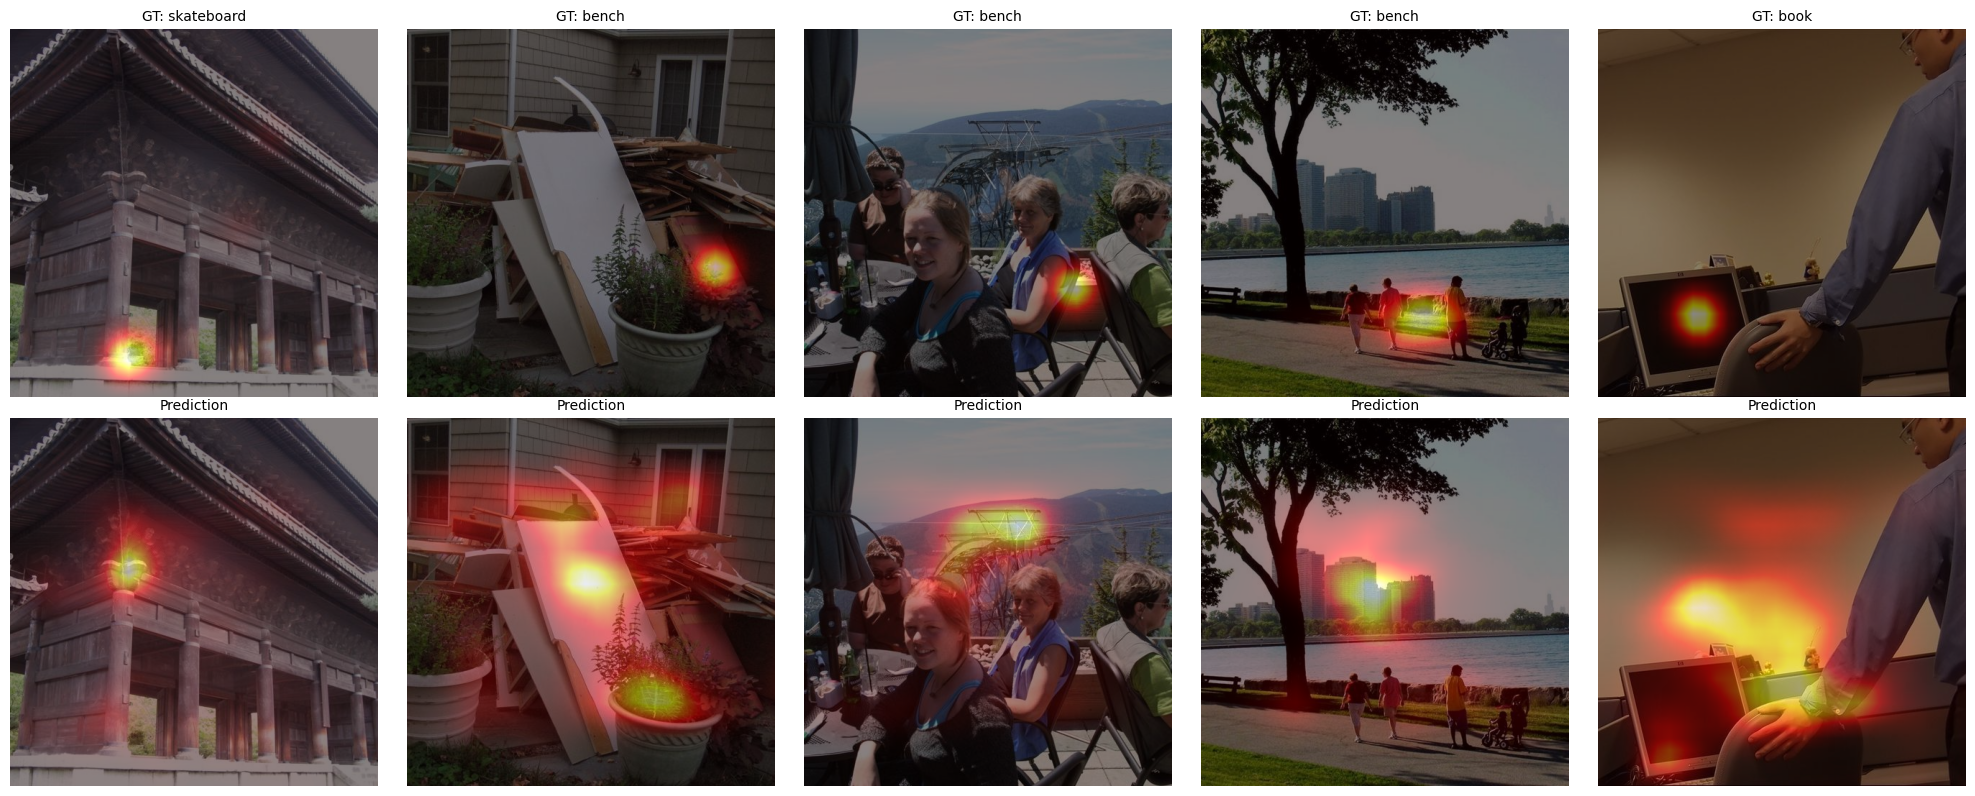

In [2]:
np.random.seed(0)
sample_ids = np.random.choice(len(index), size=5, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for col, sid in enumerate(sample_ids):
    item = index[sid]

    # Load image
    img = load_scene_image(item["bg_path"])
    img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
    img_tensor = img_tensor.unsqueeze(0).to(device)

    # Class embedding
    cls_emb = class_embeddings[item["fg_class"]].unsqueeze(0).to(device)

    # Forward
    with torch.no_grad():
        logits = model(img_tensor, cls_emb)
        probs = torch.softmax(logits.flatten(1), dim=1).reshape(1, 8, 32, 32)

    pred_2d = probs[0].sum(dim=0).cpu().numpy()
    pred_2d_up = zoom(pred_2d, 512 / 32, order=1)

    # Load target
    target_data = np.load(item["target_path"])
    target = target_data["target"]
    target_2d = target.sum(axis=0)
    target_2d_up = zoom(target_2d, 512 / 32, order=1)

    # GT row
    axes[0, col].imshow(img)
    axes[0, col].imshow(target_2d_up, cmap="hot", alpha=0.5)
    axes[0, col].set_title(f"GT: {item['fg_class']}", fontsize=10)
    axes[0, col].axis("off")

    # Prediction row
    axes[1, col].imshow(img)
    axes[1, col].imshow(pred_2d_up, cmap="hot", alpha=0.5)
    axes[1, col].set_title("Prediction", fontsize=10)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()